
Loaded files (sorted by distance):
messung 53cm.tiff   z= 0.53 m  Dx=  9.512 mm  Dy=  9.265 mm
messung 200 cm.tiff  z= 2.00 m  Dx=  9.297 mm  Dy=  9.739 mm
messung 350cm.tiff  z= 3.50 m  Dx=  9.615 mm  Dy= 10.012 mm
messung 500cm.tiff  z= 5.00 m  Dx=  9.930 mm  Dy= 10.128 mm
messung 750cm.tiff  z= 7.50 m  Dx= 10.173 mm  Dy= 10.327 mm

==================== ISO 11146 (2nd moment) Fit ====================
X: M^2=1.132  w0=2.348 mm  z0=-0.680 m  zR=19.124 m
Y: M^2=1.123  w0=2.378 mm  z0=-1.470 m  zR=19.781 m
--------------------------------------------------------------------
Effective wavefront radius at first plane z1=0.530 m:
  Rx(z1) = 303.437 m
  Ry(z1) = 197.651 m



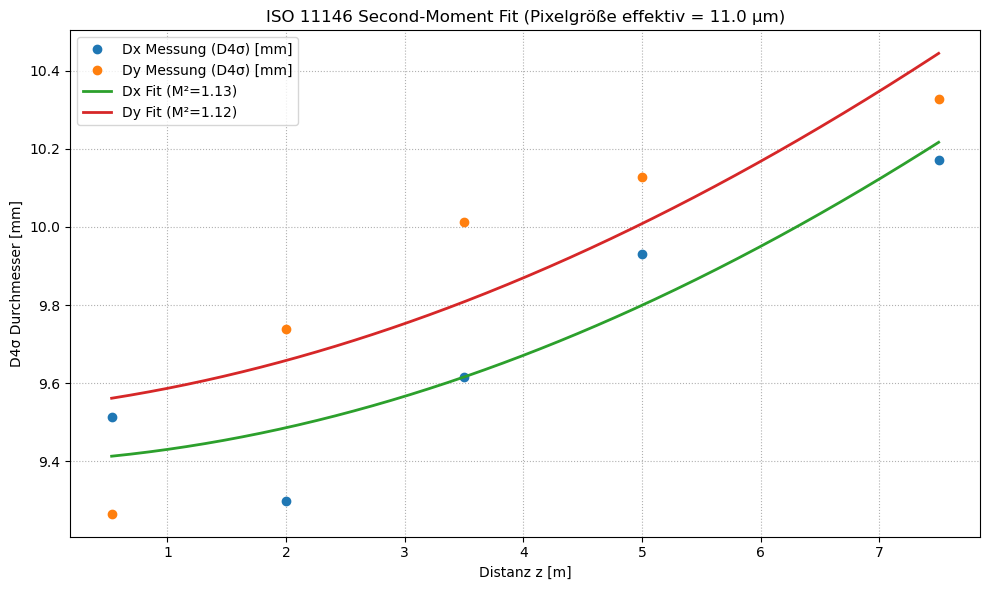

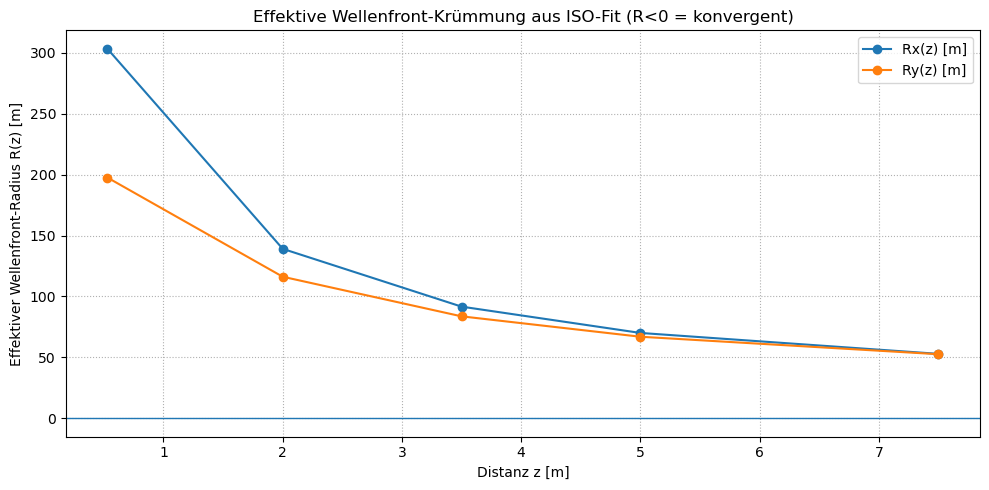

In [10]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# TOP-HAT / REAL BEAM: Rx, Ry aus reinen Intensitätsbildern
# (ISO 11146 Second-Moment Fit -> effektive z0, w0, M² -> R(z))
# ============================================================

# ----------------------------
# USER SETTINGS
# ----------------------------
LAM = 800e-9                 # [m] Wellenlänge
PIXEL_SIZE = 5.5e-6          # [m] Kamerapixel (physikalisch)
SIZE_FACTOR = 2.0            # <-- WICHTIG: deine Bilder sind "doppelt so groß" -> Pixelgröße *2
THRESHOLD = 20.0             # Intensitätsschwelle (None = aus)

FILE_GLOB = "messung*.tiff"  # z.B. messung 53cm.tiff, messung 200 cm.tiff, ...

# z0-Suchbereich (erweitern, falls nötig)
Z0_MARGIN = 2.0              # [m] z0 darf um min/max herum liegen

# ============================================================
# IO + Parsing
# ============================================================

def load_tiff(path: Path, threshold: float | None) -> np.ndarray:
    arr = np.array(Image.open(path), dtype=np.float64)
    if threshold is not None:
        arr[arr < threshold] = 0.0
    return arr

def extract_distance_m(name: str) -> float:
    """
    Erwartet "...53cm..." oder "...200 cm..." etc.
    Gibt z in [m] zurück.
    """
    m = re.search(r"(\d+(?:[.,]\d+)?)\s*cm", name.lower())
    if not m:
        raise ValueError(f"Kein '...cm' im Dateinamen gefunden: {name}")
    cm = float(m.group(1).replace(",", "."))
    return cm / 100.0

# ============================================================
# Second-moment Beam Sizes (ISO 11146)
# ============================================================

def second_moments_sizes(I: np.ndarray, dx: float):
    """
    Liefert Dx, Dy als D4σ-Durchmesser [m] (ISO second-moment).
    Dx = 4*sqrt(<(x-x0)^2>), Dy analog.
    """
    h, w = I.shape
    if I.sum() <= 0:
        return np.nan, np.nan

    x = (np.arange(w) - w/2) * dx
    y = (np.arange(h) - h/2) * dx
    X, Y = np.meshgrid(x, y)

    P = I / I.sum()
    x0 = np.sum(X * P)
    y0 = np.sum(Y * P)

    var_x = np.sum(P * (X - x0)**2)
    var_y = np.sum(P * (Y - y0)**2)

    Dx = 4.0 * np.sqrt(max(var_x, 0.0))
    Dy = 4.0 * np.sqrt(max(var_y, 0.0))
    return Dx, Dy

# ============================================================
# Fit: w(z)^2 = w0^2 + (θ*(z-z0))^2  (θ = Divergenz-Halbwinkel)
# Für beliebige Strahlen über 2. Momente sinnvoll (ISO 11146)
# ============================================================

def fit_w2_vs_z(z: np.ndarray, w: np.ndarray, lam: float):
    """
    Fit für ein Achsenprofil:
      w(z)^2 = w0^2 + B*(z-z0)^2,  B = θ^2
    via Grid-Search über z0 und linearem LS für (w0^2, B).
    Gibt zurück:
      w0, z0, M2, zR, theta, rss
    """
    z = np.asarray(z, float)
    w = np.asarray(w, float)

    m = np.isfinite(z) & np.isfinite(w) & (w > 0)
    z = z[m]
    w = w[m]
    if len(z) < 3:
        raise RuntimeError("Zu wenige gültige Messpunkte für Fit.")

    w2 = w**2

    zmin, zmax = float(z.min()), float(z.max())
    z0_candidates = np.linspace(zmin - Z0_MARGIN, zmax + Z0_MARGIN, 2001)

    best = None
    for z0 in z0_candidates:
        dz2 = (z - z0)**2
        A = np.vstack([np.ones_like(dz2), dz2]).T  # w2 = a + b*dz2
        (a, b), *_ = np.linalg.lstsq(A, w2, rcond=None)
        if a <= 0 or b < 0:
            continue
        pred = a + b*dz2
        rss = float(np.sum((w2 - pred)**2))
        if (best is None) or (rss < best["rss"]):
            best = {"z0": z0, "a": a, "b": b, "rss": rss}

    if best is None:
        raise RuntimeError("Fit fehlgeschlagen (keine sinnvolle Lösung gefunden).")

    w0 = np.sqrt(best["a"])
    theta = np.sqrt(best["b"])  # [rad] (small angle)
    # ISO-Relation: theta = M^2 * lam / (pi*w0)
    M2 = (np.pi * w0 / lam) * theta
    zR = w0 / theta if theta > 0 else np.inf

    return {
        "w0": float(w0),
        "z0": float(best["z0"]),
        "theta": float(theta),
        "M2": float(M2),
        "zR": float(zR),
        "rss": float(best["rss"]),
    }

def wavefront_radius_R(z: np.ndarray, z0: float, zR: float):
    """
    Effektiver Wellenfront-Radius wie beim Gauß-Formalismus:
      R(z) = (z-z0) * (1 + (zR/(z-z0))^2)
    Vor dem Waist (z<z0) wird R negativ (konvergent).
    """
    z = np.asarray(z, float)
    dz = z - z0
    R = np.full_like(dz, np.nan, dtype=float)
    eps = 1e-12
    m = np.abs(dz) > eps
    R[m] = dz[m] * (1.0 + (zR / dz[m])**2)
    return R

# ============================================================
# MAIN
# ============================================================

def main():
    base = Path().resolve()
    files = sorted(base.glob(FILE_GLOB))
    if not files:
        raise RuntimeError(f"Keine Dateien gefunden: {base / FILE_GLOB}")

    dx_eff = PIXEL_SIZE * SIZE_FACTOR  # <-- deine „*2“-Korrektur sitzt hier

    rows = []
    for p in files:
        try:
            z_m = extract_distance_m(p.name)
        except ValueError:
            continue

        I = load_tiff(p, THRESHOLD)
        Dx, Dy = second_moments_sizes(I, dx_eff)  # [m]
        rows.append((z_m, Dx, Dy, p.name))

    if not rows:
        raise RuntimeError("Keine gültigen Messdateien (mit 'cm' im Namen) gefunden.")

    # Sortiert nach Distanz
    rows.sort(key=lambda r: r[0])

    z = np.array([r[0] for r in rows], float)
    Dx = np.array([r[1] for r in rows], float)
    Dy = np.array([r[2] for r in rows], float)

    # ISO verwendet typischerweise w = 2σ (Radius). Bei D4σ gilt: D = 4σ -> σ = D/4
    # Wir setzen w_sigma = σ  (zweiter Moment Radius); das passt konsistent zum Fit oben
    wx = Dx / 4.0
    wy = Dy / 4.0

    print("\nLoaded files (sorted by distance):")
    for zi, dxi, dyi, name in rows:
        print(f"{name:18s}  z={zi:5.2f} m  Dx={dxi*1e3:7.3f} mm  Dy={dyi*1e3:7.3f} mm")

    fit_x = fit_w2_vs_z(z, wx, LAM)
    fit_y = fit_w2_vs_z(z, wy, LAM)

    Rx = wavefront_radius_R(z, fit_x["z0"], fit_x["zR"])
    Ry = wavefront_radius_R(z, fit_y["z0"], fit_y["zR"])

    z1 = float(z[0])
    Rx1 = float(Rx[0])
    Ry1 = float(Ry[0])

    print("\n==================== ISO 11146 (2nd moment) Fit ====================")
    print(f"X: M^2={fit_x['M2']:.3f}  w0={fit_x['w0']*1e3:.3f} mm  z0={fit_x['z0']:.3f} m  zR={fit_x['zR']:.3f} m")
    print(f"Y: M^2={fit_y['M2']:.3f}  w0={fit_y['w0']*1e3:.3f} mm  z0={fit_y['z0']:.3f} m  zR={fit_y['zR']:.3f} m")
    print("--------------------------------------------------------------------")
    print(f"Effective wavefront radius at first plane z1={z1:.3f} m:")
    print(f"  Rx(z1) = {Rx1:.3f} m")
    print(f"  Ry(z1) = {Ry1:.3f} m")
    print("====================================================================\n")

    # ---------- Plot: Dx/Dy + Fit ----------
    z_plot = np.linspace(z.min(), z.max(), 400)

    def model_D(zp, fit):
        # w(z)^2 = w0^2 + theta^2*(z-z0)^2 ; D4σ = 4*w_sigma = 4*w
        w2 = fit["w0"]**2 + (fit["theta"]**2) * (zp - fit["z0"])**2
        w = np.sqrt(np.maximum(w2, 0.0))
        return 4.0 * w

    Dx_fit = model_D(z_plot, fit_x)
    Dy_fit = model_D(z_plot, fit_y)

    plt.figure(figsize=(10, 6))
    plt.plot(z, Dx*1e3, "o", label="Dx Messung (D4σ) [mm]")
    plt.plot(z, Dy*1e3, "o", label="Dy Messung (D4σ) [mm]")
    plt.plot(z_plot, Dx_fit*1e3, "-", lw=2, label=f"Dx Fit (M²={fit_x['M2']:.2f})")
    plt.plot(z_plot, Dy_fit*1e3, "-", lw=2, label=f"Dy Fit (M²={fit_y['M2']:.2f})")
    plt.xlabel("Distanz z [m]")
    plt.ylabel("D4σ Durchmesser [mm]")
    plt.title(f"ISO 11146 Second-Moment Fit (Pixelgröße effektiv = {dx_eff*1e6:.1f} µm)")
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------- Plot: R(z) ----------
    plt.figure(figsize=(10, 5))
    plt.plot(z, Rx, "o-", label="Rx(z) [m]")
    plt.plot(z, Ry, "o-", label="Ry(z) [m]")
    plt.axhline(0, lw=1)
    plt.xlabel("Distanz z [m]")
    plt.ylabel("Effektiver Wellenfront-Radius R(z) [m]")
    plt.title("Effektive Wellenfront-Krümmung aus ISO-Fit (R<0 = konvergent)")
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
